In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Указываем ссылку, которую будем парсить
url = 'https://career.habr.com/vacancies?q=data+scientist&type=all'

# 2. Притворяемся настоящим человеком (браузером), чтобы сайт нас не забанил
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
}

# 3. Отправляем запрос к сайту
response = requests.get(url, headers=headers)

# Проверяем, пустил ли нас сайт (код 200 - всё ОК)
print(f"Статус ответа: {response.status_code}")

# 4. Превращаем страшный HTML-код в удобный объект "супа"
soup = BeautifulSoup(response.text, 'html.parser')

# 5. ИЩЕМ ДАННЫЕ! 
# На Хабр Карьере карточки вакансий обычно лежат в классе 'vacancy-card'
vacancies = soup.find_all('div', class_='vacancy-card')
print(f"Найдено вакансий на странице: {len(vacancies)}")

# 6. Проходимся циклом по каждой карточке и вытаскиваем название
for job in vacancies:
    # Ищем заголовок внутри карточки
    title_element = job.find('div', class_='vacancy-card__title')
    
    if title_element:
        title = title_element.text.strip()
        print(f"Вакансия: {title}")

Статус ответа: 200
Найдено вакансий на странице: 25
Вакансия: Data Scientist
Вакансия: Data Scientist
Вакансия: Data Scientist (NLP|LLM)
Вакансия: Lead Data Scientist (LLM)
Вакансия: Data Scientist
Вакансия: Data Scientist / Deep Learning engineer (нейронные сети / Time Series / NLP)
Вакансия: Data Engineer
Вакансия: Data Engineer
Вакансия: Архитектор (Data/AI)
Вакансия: Data analyst
Вакансия: Data Engineer
Вакансия: Data Steward/Менеджер по данным
Вакансия: Data Engineer
Вакансия: Data Engineer (разработчик DWH)
Вакансия: Data Engineer/Дата инженер (ученик)
Вакансия: Инженер качества данных/Data Quality Engineer
Вакансия: Аналитик данных
Вакансия: Старший Data Engineer
Вакансия: BI разработчик
Вакансия: Project Manager (BigData)
Вакансия: Руководитель группы разработки в Data center infrastructure management
Вакансия: Lead ML Engineer (Computer Vision)
Вакансия: Middle/Senior DevOps Engineer [МТС Веб Сервисы]
Вакансия: Product Analyst
Вакансия: Архитектор MLOps


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = 'https://career.habr.com/vacancies?q=data+scientist&type=all'
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')
vacancies = soup.find_all('div', class_='vacancy-card')

# 1. Создаем пустой список, куда будем складывать все данные
parsed_data = []

for job in vacancies:
    # Название вакансии
    title_element = job.find('div', class_='vacancy-card__title')
    title = title_element.text.strip() if title_element else 'Не указано'
    
    # Название компании (Новый правильный класс!)
    company_element = job.find('div', class_='vacancy-card__company')
    company = company_element.text.strip() if company_element else 'Не указано'
    
    # Зарплата (Новый правильный класс!)
    salary_element = job.find('div', class_='vacancy-card__salary')
    salary = salary_element.text.strip() if salary_element else 'Не указана'

    # Скиллы (Расклеиваем их запятыми)
    skills_element = job.find('div', class_='vacancy-card__skills')
    skills = skills_element.get_text(separator=', ').strip() if skills_element else 'Не указаны'

    # 2. Формируем словарь с данными одной вакансии и добавляем его в общий список
    parsed_data.append({
        'Название': title,
        'Компания': company,
        'Зарплата': salary,
        'Навыки': skills
    })

# 3. МАГИЯ: Превращаем список словарей в красивый датафрейм Pandas!
df_jobs = pd.DataFrame(parsed_data)

# Выводим первые 10 строк таблицы
df_jobs.head(10)

,Название,Компания,Зарплата,Навыки
0,Data Scientist,Фарпост,Зарплата не указанаПохожие специалисты получаю...,"Deep Learning, SQL, Python"
1,Data Scientist,М Тех,Не указана,"SQL, Python"
2,Data Scientist (NLP|LLM),СберЗдоровье4.45,Зарплата не указанаПохожие специалисты получаю...,"NLP, LLM, Компьютерное зрение, Python"
3,Lead Data Scientist (LLM),IT-центр МГТУ им. Н.Э. Баумана,Не указана,"Python, LLM, NLP"
4,Data Scientist,М Тех,Не указана,"Python, SQL, Apache Kafka"
5,Data Scientist / Deep Learning engineer (нейро...,Spice IT4.54,Зарплата не указанаПохожие специалисты получаю...,"PyTorch, Keras, TensorFlow, Deep Learning, Ней..."
6,Data Engineer,М Тех,Зарплата не указанаПохожие специалисты получаю...,"ClickHouse, Greenplum, Apache Airflow, Apache ..."
7,Data Engineer,Т-Банк4.42,Не указана,"Greenplum, SQL, Python, Apache Airflow, ETL, D..."
8,Архитектор (Data/AI),СберЗдоровье4.45,Зарплата не указанаПохожие специалисты получаю...,"Python, DWH, ETL, Apache Airflow, Объектное хр..."
9,Data analyst,ИТ-компания «Лоция»,Зарплата не указанаПохожие специалисты получаю...,PostgreSQL


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time # Библиотека для пауз

# 1. Задаем базовые настройки
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
}

parsed_data = []

# 2. ЗАПУСКАЕМ ЦИКЛ ПО СТРАНИЦАМ (например, первые 5 страниц)
for page in range(1, 6):
    print(f"Собираю данные со страницы {page}...")
    
    # Обрати внимание: в конец ссылки мы добавляем номер страницы (&page=)
    url = f'https://career.habr.com/vacancies?q=data+scientist&type=all&page={page}'
    
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    vacancies = soup.find_all('div', class_='vacancy-card')
    
    for job in vacancies:
        # Название
        title_element = job.find('div', class_='vacancy-card__title')
        title = title_element.text.strip() if title_element else 'Не указано'
        
        # Компания (хитрость: берем только текст ссылки <a> внутри класса компании, там нет рейтинга)
        company_div = job.find('div', class_='vacancy-card__company')
        company_a = company_div.find('a') if company_div else None
        company = company_a.text.strip() if company_a else 'Не указано'
        
        # Зарплата (Очистка текста: отрезаем всё, что идет после слова "Похожие")
        salary_element = job.find('div', class_='vacancy-card__salary')
        raw_salary = salary_element.text.strip() if salary_element else 'Не указана'
        salary = raw_salary.split('Похожие')[0].strip()
        
        # Скиллы
        skills_element = job.find('div', class_='vacancy-card__skills')
        skills = skills_element.get_text(separator=', ').strip() if skills_element else 'Не указаны'

        parsed_data.append({
            'Название': title,
            'Компания': company,
            'Зарплата': salary,
            'Навыки': skills
        })
        
    # 3. Делаем паузу в 1 секунду между страницами, чтобы имитировать поведение человека
    time.sleep(1)

print("Сбор завершен! 🚀")

# Собираем DataFrame и смотрим размер
df_jobs = pd.DataFrame(parsed_data)
print(f"Всего собрано вакансий: {len(df_jobs)}")

# Сохраняем это в CSV файл, чтобы данные остались у нас навсегда!
df_jobs.to_csv('habr_vacancies.csv', index=False)

df_jobs.head(10)

Собираю данные со страницы 1...
Собираю данные со страницы 2...
Собираю данные со страницы 3...
Собираю данные со страницы 4...
Собираю данные со страницы 5...
Сбор завершен! 🚀
Всего собрано вакансий: 74


,Название,Компания,Зарплата,Навыки
0,Data Scientist,Фарпост,Зарплата не указана,"Deep Learning, SQL, Python"
1,Data Scientist,М Тех,Не указана,"SQL, Python"
2,Data Scientist (NLP|LLM),СберЗдоровье,Зарплата не указана,"NLP, LLM, Компьютерное зрение, Python"
3,Lead Data Scientist (LLM),IT-центр МГТУ им. Н.Э. Баумана,Не указана,"Python, LLM, NLP"
4,Data Scientist,М Тех,Не указана,"Python, SQL, Apache Kafka"
5,Data Scientist / Deep Learning engineer (нейро...,Spice IT,Зарплата не указана,"PyTorch, Keras, TensorFlow, Deep Learning, Ней..."
6,Data Engineer,М Тех,Зарплата не указана,"ClickHouse, Greenplum, Apache Airflow, Apache ..."
7,Data Engineer,Т-Банк,Не указана,"Greenplum, SQL, Python, Apache Airflow, ETL, D..."
8,Архитектор (Data/AI),СберЗдоровье,Зарплата не указана,"Python, DWH, ETL, Apache Airflow, Объектное хр..."
9,Data analyst,ИТ-компания «Лоция»,Зарплата не указана,PostgreSQL


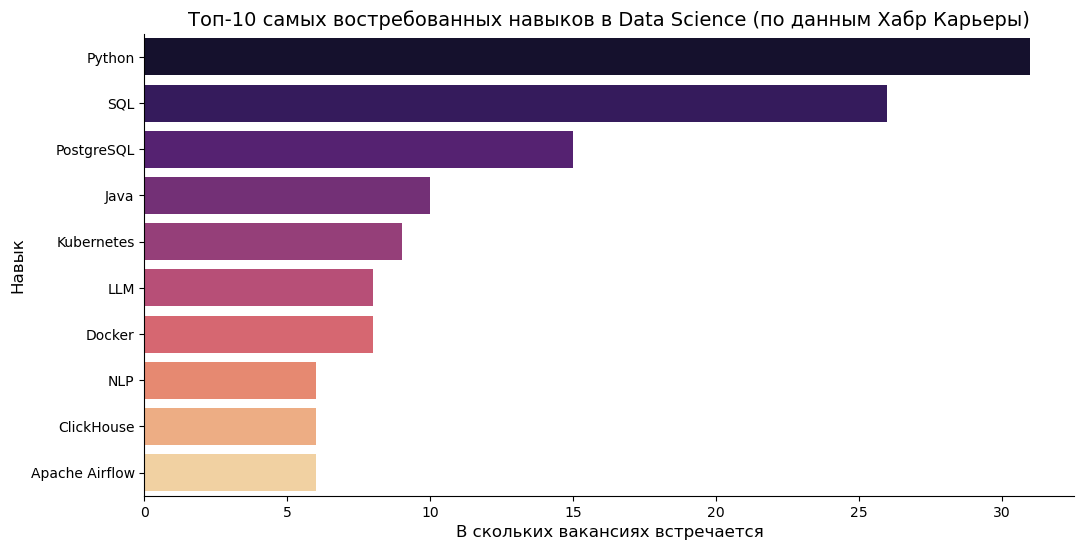

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Читаем наш свежесобранный датасет
df = pd.read_csv('habr_vacancies.csv')

# Оставляем только те вакансии, где навыки реально указаны
skills_data = df[df['Навыки'] != 'Не указаны']['Навыки']

# 2. Собираем все скиллы в один гигантский список
all_skills = []
for row in skills_data:
    # Разбиваем строку по запятой и убираем лишние пробелы по краям
    skills = [skill.strip() for skill in row.split(',')]
    all_skills.extend(skills)

# 3. Считаем топ-10 самых частых навыков с помощью Counter
top_10_skills = Counter(all_skills).most_common(10)

# Превращаем это в табличку Pandas для удобной отрисовки
df_top_skills = pd.DataFrame(top_10_skills, columns=['Навык', 'Количество упоминаний'])

# 4. Рисуем красивый бизнес-график (без предупреждений!)
plt.figure(figsize=(12, 6))

# Добавили hue='Навык' и legend=False
sns.barplot(
    x='Количество упоминаний', 
    y='Навык', 
    data=df_top_skills, 
    palette='magma',
    hue='Навык',
    legend=False
)

plt.title('Топ-10 самых востребованных навыков в Data Science (по данным Хабр Карьеры)', fontsize=14)
plt.xlabel('В скольких вакансиях встречается', fontsize=12)
plt.ylabel('Навык', fontsize=12)
sns.despine() # Убираем лишние рамки

plt.show()